# Specification multiverse: how much do city rankings move?

## tl;dr

Across **32 defensible specifications**, the league table moves
materially. Crawley finishes in the top five in
**17/20** applicable
specifications but ranges from rank **1** to
**27**. Sheffield finishes top five in
**21/32** and
ranges from **1** to
**15**; London ranges from
**1** to **32**. These are
specification ranges, not sampling confidence intervals.

## Context and methods

The study review recommends replacing a single exact rank with a multiverse of
defensible design choices. This experiment combines:

- balanced city-first catalogues covering 10 and 20 FUAs;
- popularity-first catalogues of 100, 200 and 1,000 bands;
- monthly listeners, followers and selected-band counts;
- raw totals, per-capita scores, largest-band exclusion and output quotients;
- strict and reviewed-extended FUA mappings; and
- negative-binomial count residuals and log–log follower residuals.

### Assumptions

Each specification receives equal descriptive weight. A city is summarized
only across specifications in which it is eligible. The resulting rank range
measures design sensitivity; it is not a probability interval and does not
make the editorial catalogues random samples.

## Data

Load the frozen experiment inputs and rebuild every rank.

In [1]:
from pathlib import Path
import json
import sys

import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path.cwd().resolve()
if not (ROOT / "src/python_uk_bands").exists():
    ROOT = next(
        parent for parent in Path.cwd().resolve().parents
        if (parent / "src/python_uk_bands").exists()
    )
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

ARTIFACT_DIR = ROOT / "artifacts/experiments/specification_multiverse/20260718T204522Z"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
from python_uk_bands.review_experiments import (
    build_specification_multiverse,
    plot_rank_intervals,
    plot_top_finish_share,
)

ranked, stability, specification_catalogue = build_specification_multiverse(ROOT)

assert specification_catalogue["specification"].nunique() == 32
assert not ranked.duplicated(["specification", "study_city_label"]).any()
assert ranked["rank"].ge(1).all()
assert stability["top_finish_share"].between(0, 1).all()

ranked.to_csv(ARTIFACT_DIR / "ranked_specifications.csv", index=False)
stability.to_csv(ARTIFACT_DIR / "rank_stability.csv", index=False)
specification_catalogue.to_csv(
    ARTIFACT_DIR / "specification_catalogue.csv", index=False
)

display(Markdown(
    f"**{len(specification_catalogue)} specifications · "
    f"{ranked['study_city_label'].nunique()} FUAs appear at least once · "
    f"{len(ranked):,} city-specification ranks**"
))
display(specification_catalogue.groupby("family", as_index=False).agg(
    specifications=("specification", "nunique"),
    minimum_eligible_cities=("eligible_cities", "min"),
    maximum_eligible_cities=("eligible_cities", "max"),
))

**32 specifications · 83 FUAs appear at least once · 1,816 city-specification ranks**

,family,specifications,minimum_eligible_cities,maximum_eligible_cities
0,balanced city-first,12,10,20
1,expected-output residual,2,59,83
2,popularity-first output quotient,18,83,83


## Results

### 1. Which cities remain near the top most often?

In [3]:
top_stability = stability.head(15)[[
    "study_city_label",
    "specifications",
    "best_rank",
    "median_rank",
    "worst_rank",
    "top_finishes",
    "top_finish_share",
]].copy()
display(top_stability.style.hide(axis="index").format({
    "median_rank": "{:.1f}",
    "top_finish_share": "{:.0%}",
}))

study_city_label,specifications,best_rank,median_rank,worst_rank,top_finishes,top_finish_share
Crawley,20,1,1.0,27,17,85%
Bath and North East Somerset,20,1,5.0,11,15,75%
Oxford,26,1,3.0,13,18,69%
London,32,1,4.0,29,20,62%
Sheffield,32,1,2.5,13,19,59%
Hastings,20,2,6.0,20,9,45%
Liverpool,32,2,6.0,16,13,41%
Manchester,32,2,10.5,30,12,38%
Birmingham,32,3,15.0,53,10,31%
Cambridge,20,5,10.0,16,6,30%


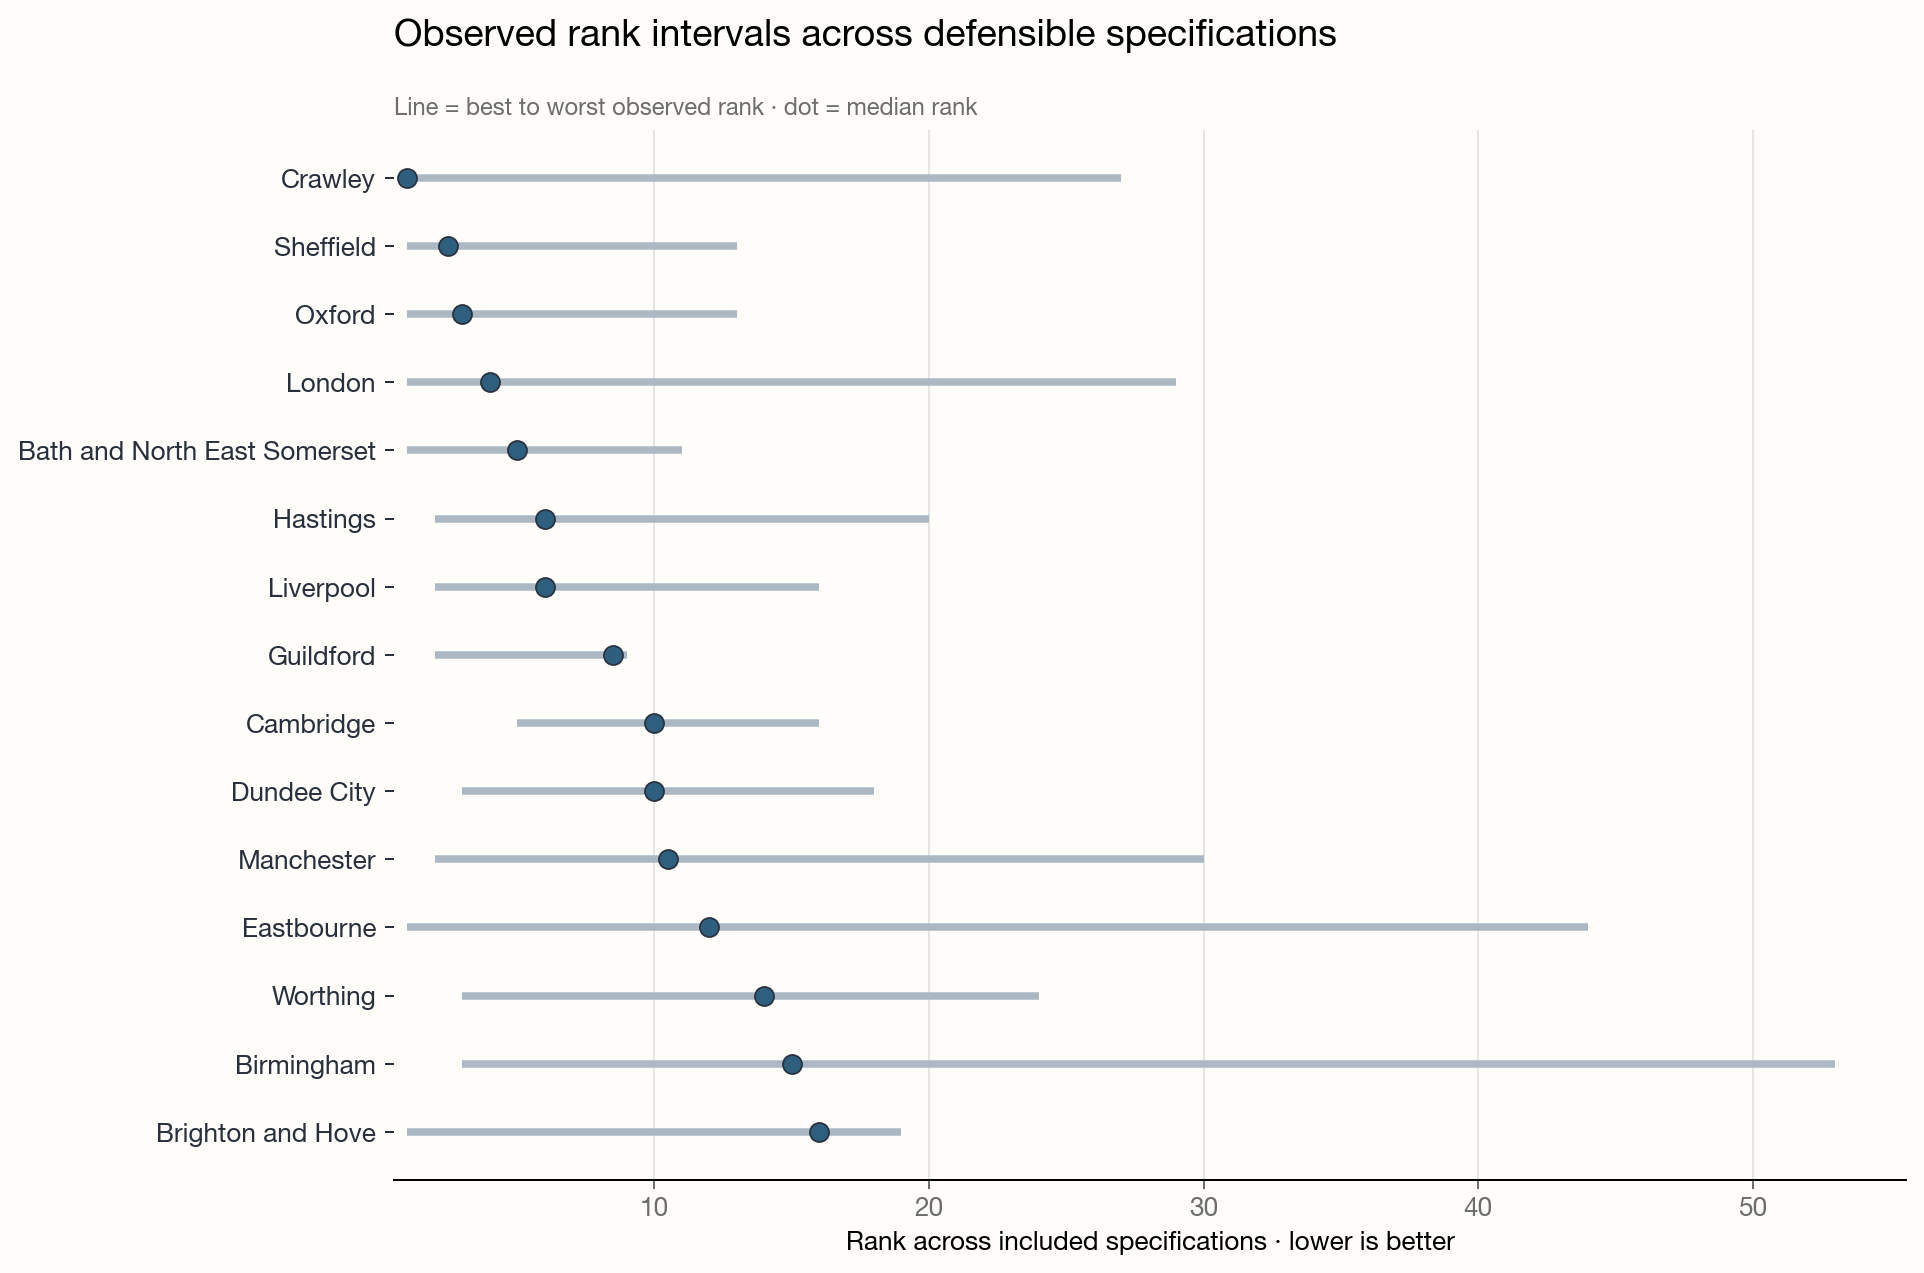

In [4]:
interval_path = plot_rank_intervals(
    stability,
    output_path=ARTIFACT_DIR / "chart_01_rank_intervals.png",
)
display(Image(filename=str(interval_path)))

### 2. How frequently does each city finish in the top five?

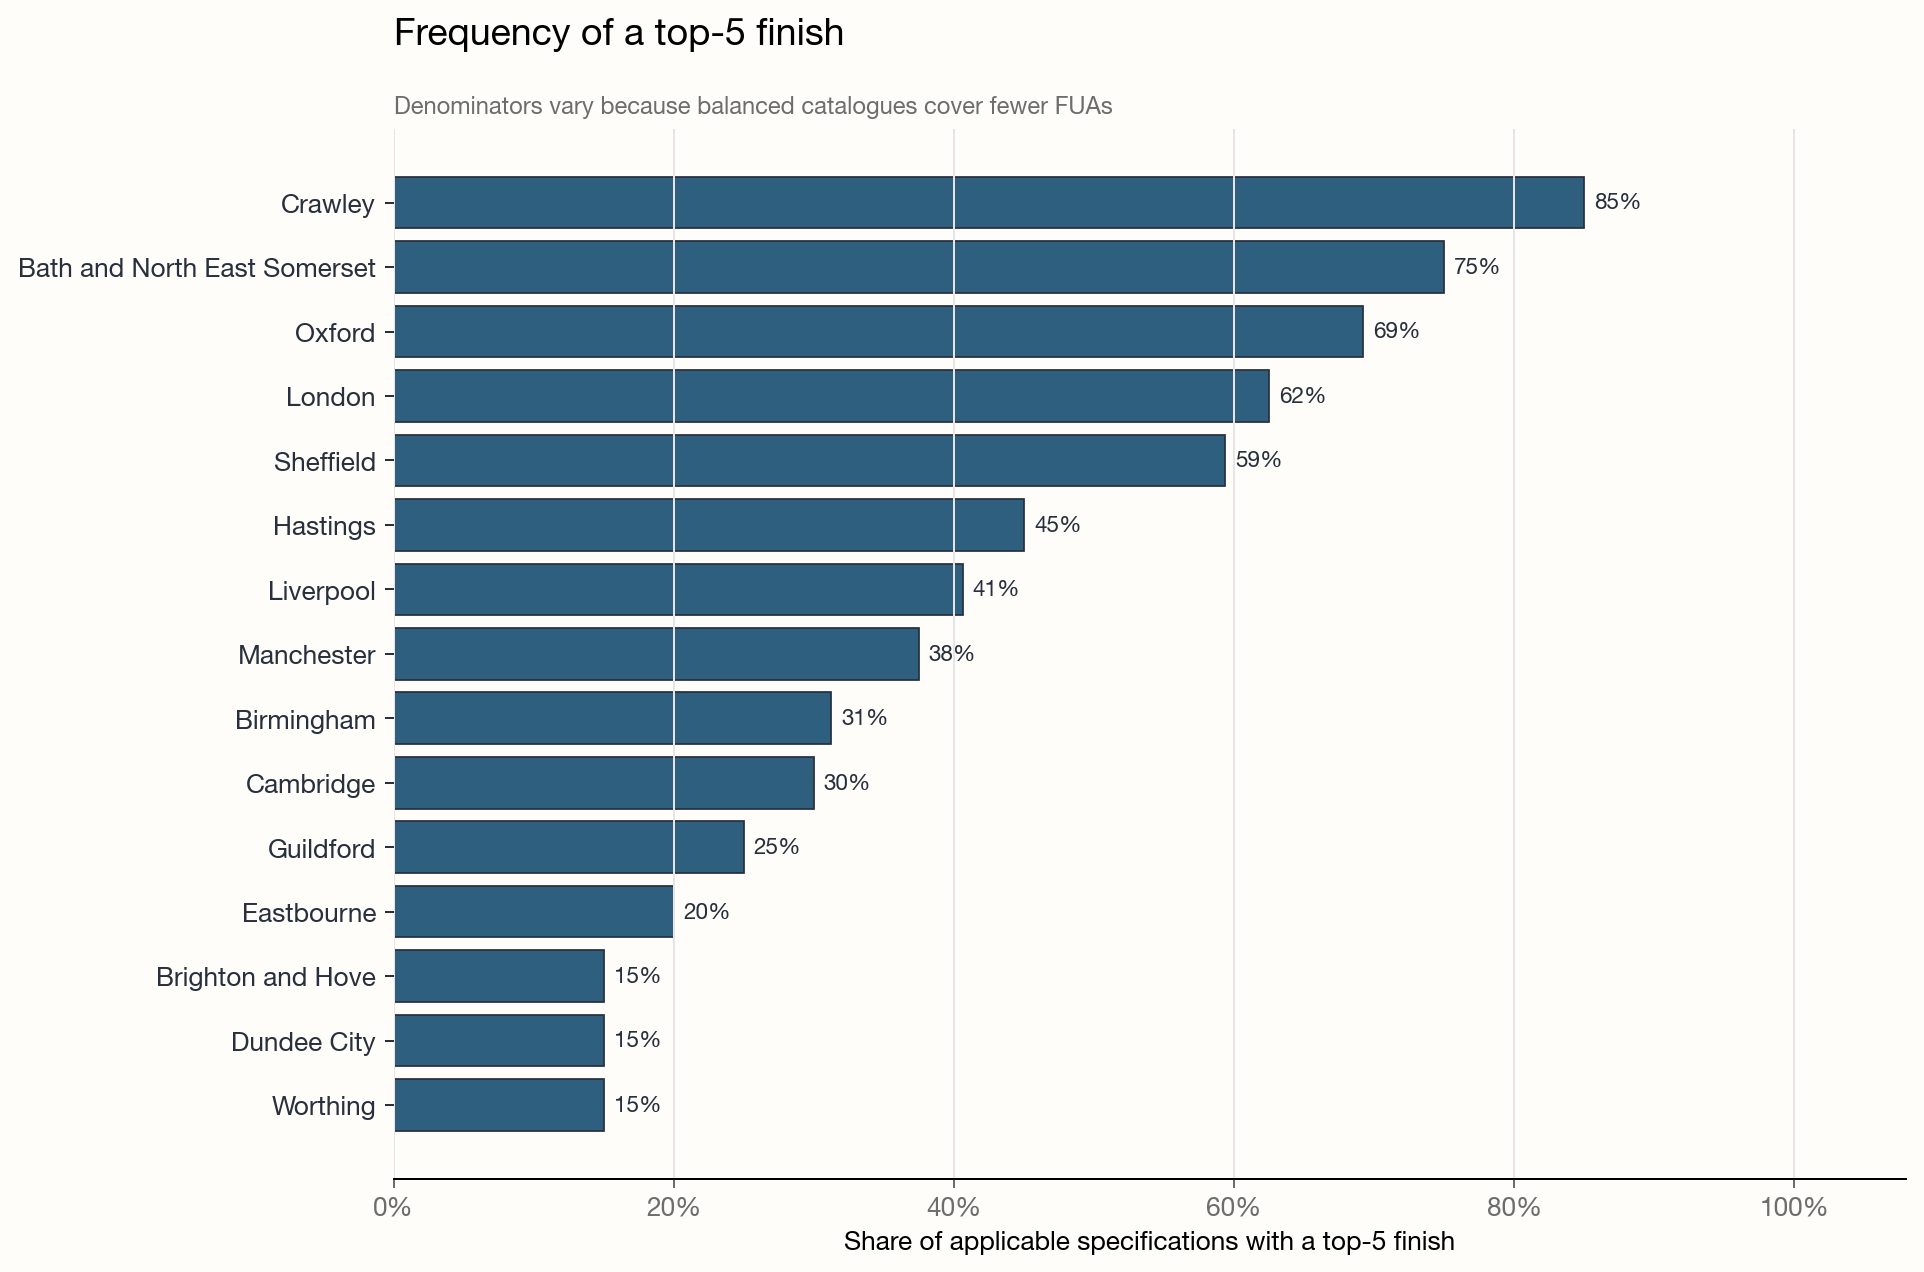

In [5]:
frequency_path = plot_top_finish_share(
    stability,
    output_path=ARTIFACT_DIR / "chart_02_top_five_frequency.png",
)
display(Image(filename=str(frequency_path)))

## Takeaways

- The ranking depends strongly on catalogue construction, geography, audience
  metric and scoring rule.
- Crawley often finishes high, but its rank range extends well outside the top
  five because it is sensitive to one band and the population denominator.
- Sheffield appears in every balanced and popularity-first specification and
  often makes the top five. It still has no single, design-independent rank.
- Publication should show rank ranges or top-five frequencies alongside any
  single preferred specification.